In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os

# 1. Load Dataset
csv_path = '../data/custom_dataset/breast_cancer.csv'

if os.path.exists(csv_path):
    print(f"Đang đọc dữ liệu từ: {csv_path}")
    df = pd.read_csv(csv_path)
else:
    # Fallback nếu không thấy file
    from sklearn.datasets import load_breast_cancer
    data = load_breast_cancer()
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df['target'] = data.target

# =========================================================
# KIỂM TRA VÀ CHỌN CỘT LABEL (QUAN TRỌNG)
# =========================================================
print("Danh sách các cột trong file CSV:")
print(df.columns.tolist())

# Thử đoán tên cột label thông dụng
possible_targets = ['target', 'diagnosis', 'class', 'label', 'Outcome']
target_col = None

# Tìm xem có cột nào trùng tên không
for col in df.columns:
    if col.lower() in possible_targets:
        target_col = col
        break

# Nếu không tìm thấy tự động, bạn hãy ĐIỀN TÊN CỘT LABEL VÀO DƯỚI ĐÂY
# Ví dụ: target_col = 'diagnosis'
if target_col is None:
    # Mặc định thử lấy cột đầu tiên hoặc cột thứ 2 (vì dataset ung thư vú UCI thường để label ở cột 2)
    # Tuy nhiên, an toàn nhất là bạn nhìn danh sách in ra ở trên và sửa dòng dưới này:
    target_col = df.columns[-1] # Tạm để cột cuối, nhưng NẾU LỖI thì bạn phải sửa tên trực tiếp ở đây.
    print(f"CẢNH BÁO: Không tìm thấy tên cột label chuẩn. Đang thử dùng cột cuối cùng: '{target_col}'")

print(f"\n---> ĐANG SỬ DỤNG CỘT LABEL LÀ: '{target_col}'")

# Xử lý nhãn nếu là dạng chữ (M/B) sang số (1/0)
if df[target_col].dtype == 'object':
    print("Label đang là dạng chữ, tiến hành mã hóa sang số...")
    # Dataset Breast Cancer thường là M (Malignant - Ác tính) và B (Benign - Lành tính)
    # Map M -> 1, B -> 0
    df[target_col] = df[target_col].map({'M': 1, 'B': 0, 'malignant': 1, 'benign': 0})
    # Nếu map xong mà còn NaN (do ký tự lạ), fill bằng 0 hoặc drop
    df = df.dropna(subset=[target_col])

# Tách X và y
X = df.drop(columns=[target_col])
# Loại bỏ cột 'id' hoặc 'Unnamed: 32' nếu có (thường gặp trong file csv tải từ mạng)
cols_to_drop = [c for c in X.columns if 'id' in c.lower() or 'unnamed' in c.lower()]
if cols_to_drop:
    print(f"Đang loại bỏ các cột không cần thiết: {cols_to_drop}")
    X = X.drop(columns=cols_to_drop)

y = df[target_col]

class_names = [str(c) for c in np.unique(y)]
feature_names = X.columns.tolist()

print(f"\nKích thước X: {X.shape}")
print(f"Kích thước y: {y.shape}")
print(f"Classes: {class_names}")
display(df.head())

Đang đọc dữ liệu từ: ../data/custom_dataset/breast_cancer.csv
Danh sách các cột trong file CSV:
['ID', 'Diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']

---> ĐANG SỬ DỤNG CỘT LABEL LÀ: 'Diagnosis'
Label đang là dạng chữ, tiến hành mã hóa sang số...
Đang loại bỏ các cột không cần thiết: ['ID']

Kích thước X: (569, 30)
Kích thước y: (569,)
Classes: ['0', '1']


,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



==================== TỶ LỆ TRAIN: 40% - TEST: 60% ====================
Confusion Matrix:
[[206   9]
 [ 21 106]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       215
           1       0.92      0.83      0.88       127

    accuracy                           0.91       342
   macro avg       0.91      0.90      0.90       342
weighted avg       0.91      0.91      0.91       342



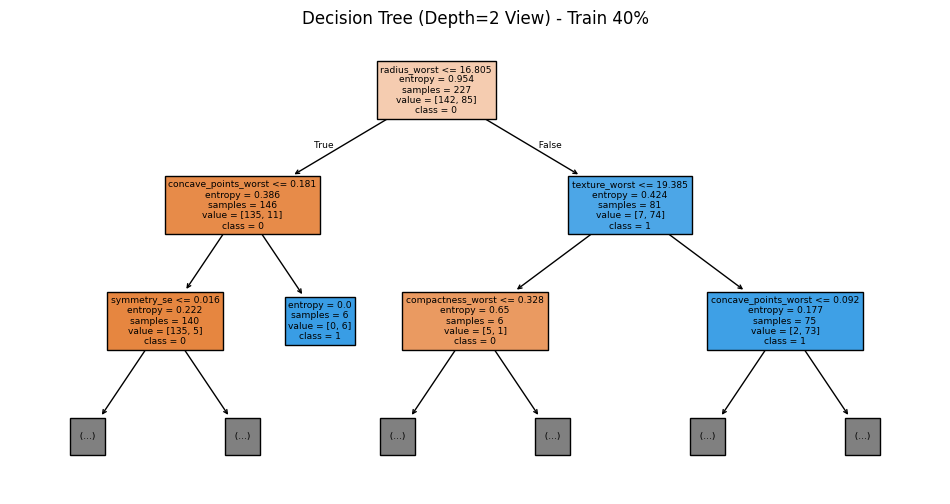


==================== TỶ LỆ TRAIN: 60% - TEST: 40% ====================
Confusion Matrix:
[[137   6]
 [  8  77]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       143
           1       0.93      0.91      0.92        85

    accuracy                           0.94       228
   macro avg       0.94      0.93      0.93       228
weighted avg       0.94      0.94      0.94       228



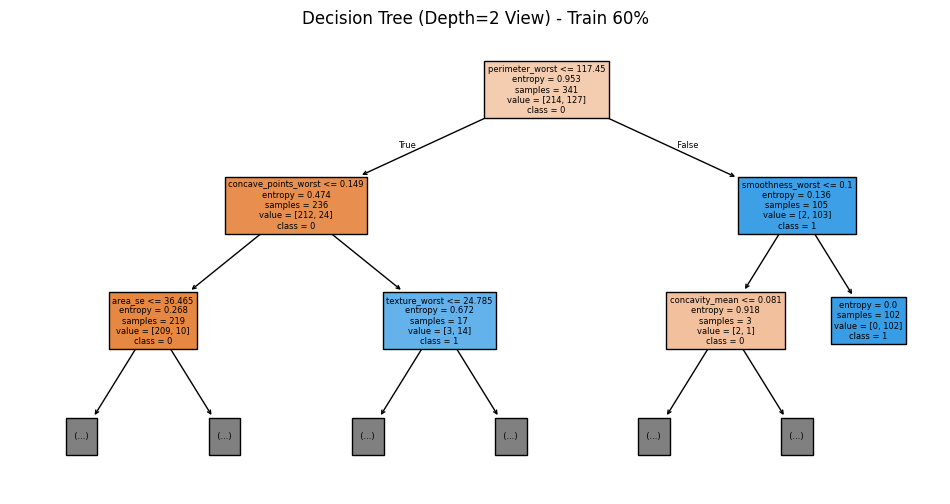


==================== TỶ LỆ TRAIN: 80% - TEST: 20% ====================
Confusion Matrix:
[[71  1]
 [ 4 38]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



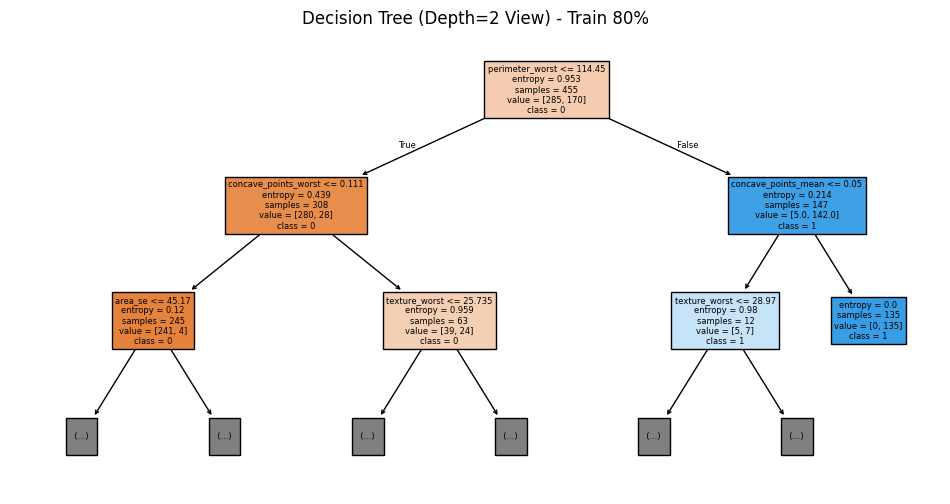


==================== TỶ LỆ TRAIN: 90% - TEST: 10% ====================
Confusion Matrix:
[[35  1]
 [ 2 19]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        36
           1       0.95      0.90      0.93        21

    accuracy                           0.95        57
   macro avg       0.95      0.94      0.94        57
weighted avg       0.95      0.95      0.95        57



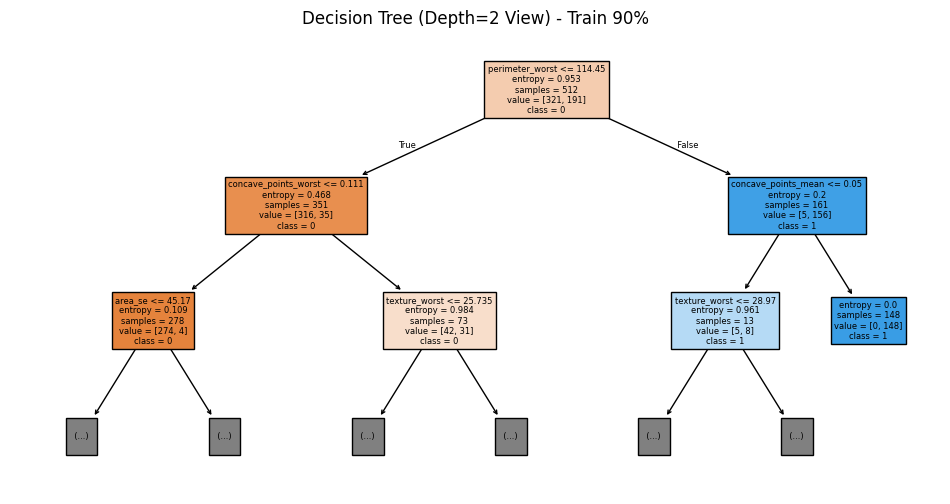

In [5]:
# Danh sách các tỷ lệ train
ratios = [0.4, 0.6, 0.8, 0.9]

for ratio in ratios:
    test_size = 1.0 - ratio
    print(f"\n{'='*20} TỶ LỆ TRAIN: {int(ratio*100)}% - TEST: {int(test_size*100 + 0.1)}% {'='*20}")
    
    # Chia dữ liệu (Stratified shuffle split) [cite: 30]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, shuffle=True, random_state=42
    )
    
    # Huấn luyện mô hình (sử dụng Entropy làm tiêu chí) [cite: 37]
    clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
    clf.fit(X_train, y_train)
    
    # Dự đoán
    y_pred = clf.predict(X_test)
    
    # Báo cáo kết quả [cite: 62]
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Vẽ cây minh họa (Chỉ vẽ độ sâu = 2 để dễ nhìn, phục vụ báo cáo)
    plt.figure(figsize=(12, 6))
    plot_tree(clf, feature_names=feature_names, class_names=class_names, filled=True, max_depth=2)
    plt.title(f"Decision Tree (Depth=2 View) - Train {int(ratio*100)}%")
    plt.show()


==================== KHẢO SÁT ĐỘ SÂU (Train 80/20) ====================
Max Depth: 2 -> Accuracy: 0.8860
Max Depth: 3 -> Accuracy: 0.9386
Max Depth: 4 -> Accuracy: 0.9298
Max Depth: 5 -> Accuracy: 0.9561
Max Depth: 6 -> Accuracy: 0.9298
Max Depth: 7 -> Accuracy: 0.9561
Max Depth: None -> Accuracy: 0.9561


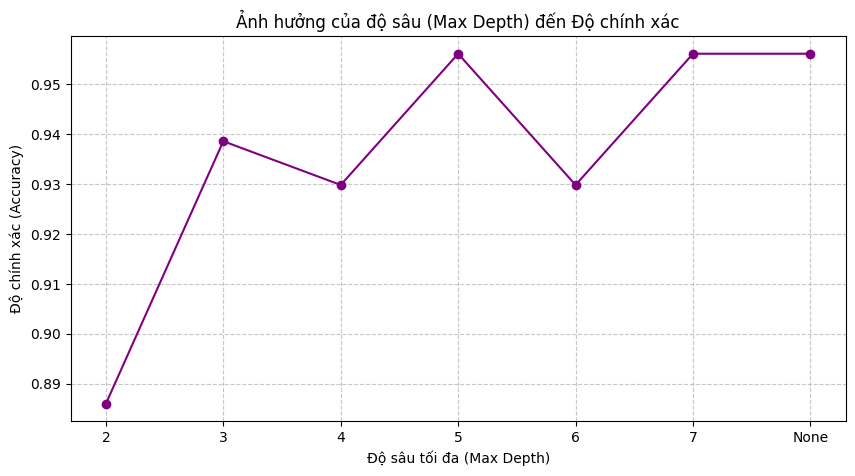

,Max Depth,Accuracy
0,2,0.885965
1,3,0.938596
2,4,0.929825
3,5,0.956140
4,6,0.929825
5,7,0.956140
6,None,0.956140


In [6]:
print(f"\n{'='*20} KHẢO SÁT ĐỘ SÂU (Train 80/20) {'='*20}")

# Cố định tập train/test 80/20 [cite: 100]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
)

# Các giá trị độ sâu cần khảo sát [cite: 103]
depths = [2, 3, 4, 5, 6, 7, None]
results = []

for depth in depths:
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    depth_label = str(depth) if depth is not None else "None"
    results.append((depth_label, acc))
    
    print(f"Max Depth: {depth_label} -> Accuracy: {acc:.4f}")

# Vẽ biểu đồ đường thể hiện độ chính xác theo độ sâu [cite: 107]
df_res = pd.DataFrame(results, columns=["Max Depth", "Accuracy"])
plt.figure(figsize=(10, 5))
plt.plot(df_res["Max Depth"], df_res["Accuracy"], marker='o', color='purple', linestyle='-')
plt.title("Ảnh hưởng của độ sâu (Max Depth) đến Độ chính xác")
plt.xlabel("Độ sâu tối đa (Max Depth)")
plt.ylabel("Độ chính xác (Accuracy)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# In bảng kết quả để copy vào báo cáo
display(df_res)